# algorithm
* initiate a matrix n x n: fill with zero
* put a 1 in first cell
* find the next pos (i, j)
    * if (i, j+1) is available, use it
    * otherwise, if (i-1, j)
    * then try (i, j-1)
    * then try (i+1, j)
* def available (i, j) -> mat[i, j] is valid pos and not occupied (0)
* put the next number

In [ ]:
def spiral_matrix(n):
    """
    Generate a spiral matrix of size n x n.
    
    :param n: Size of the matrix
    :return: Spiral matrix
    """
    if n <= 0:
        return []

    # Initialize an n x n matrix with zeros
    matrix = [[0] * n for x in range(n)]
    matrix[0][0] = 1

    deltas = [(0, +1), (+1, 0), (0, -1), (-1, 0)]
    current_direction =  0  # 0: right, 1: down, 2: left, 3: up
    current_position = 0, 0
    
    #using matrix
    def position_available(i, j):
        return 0 <= i < n and 0 <= j < n and matrix[i][j] == 0
    
    #using deltas
    def get_next_position(position, direction):
        delta = deltas[direction]
        return position[0] + delta[0], position[1] + delta[1]

    for x in range(2, n * n + 1):
        # Get the direction
        next_position = get_next_position(current_position, current_direction)
        # If the next position is not available, change direction
        if not position_available(*next_position):
            current_direction = (current_direction + 1) % 4
            next_position = get_next_position(current_position, current_direction)
        # Update the current position
        current_position  = next_position
        matrix[current_position[0]][current_position[1]] = x  
    return matrix
    
    

In [22]:
res = spiral_matrix(9)
def print_matrix(matrix):
    """
    This function prints the matrix in a readable format.
    """
    for row in matrix:
        print(" ".join(f'{x:<2}' for x in row)) 
print_matrix(res)

1  2  3  4  5  6  7  8  9 
32 33 34 35 36 37 38 39 10
31 56 57 58 59 60 61 40 11
30 55 72 73 74 75 62 41 12
29 54 71 80 81 76 63 42 13
28 53 70 79 78 77 64 43 14
27 52 69 68 67 66 65 44 15
26 51 50 49 48 47 46 45 16
25 24 23 22 21 20 19 18 17


<Axes: >

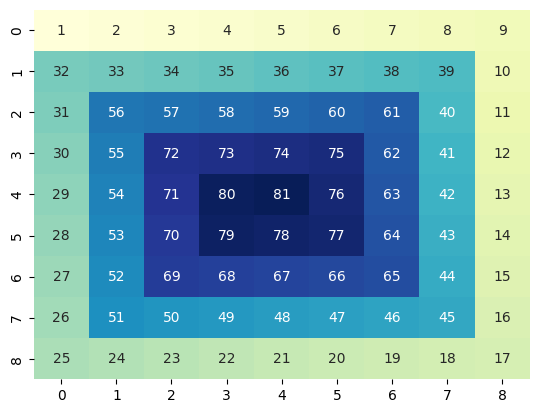

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.DataFrame(res)
sns.heatmap(df, annot=True, cmap="YlGnBu", cbar=False) #, fmt="d", )
#plt.title('Spiral Matrix')
#plt.show()

In [38]:
df_longer = pd.DataFrame([[i, j, val] for i, row in enumerate(res) for j, val in enumerate(row)], columns=['i', 'j', 'val'])

<Axes: xlabel='i', ylabel='j'>

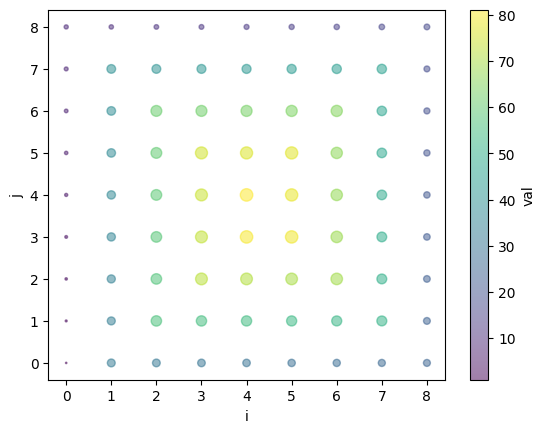

In [55]:
df_longer.plot.scatter('i', 'j', c='val', colormap='viridis', s='val', alpha=0.5)

In [51]:
# Show all rows (adjust if needed)
pd.set_option('display.max_rows', None)

# Optional: Also show all columns
pd.set_option('display.max_columns', None)

In [ ]:
df_longer

In [54]:
from IPython.display import HTML

HTML(df_longer.to_html(max_rows=2000, max_cols=10, notebook=True,
                classes='table table-striped table-hover',
                escape=False,
                table_id='scrollable-table',
                border=0,
               ) + """
<style>
#scrollable-table {
    display: block;
    max-height: 300px;
    overflow: auto;
    border: 1px solid #ccc;
}
</style>
""")

,i,j,val
0,0,0,1
1,0,1,2
2,0,2,3
3,0,3,4
4,0,4,5
5,0,5,6
6,0,6,7
7,0,7,8
8,0,8,9
9,1,0,32


In [46]:
display(df_longer)

,i,j,val
0,0,0,1
1,0,1,2
2,0,2,3
3,0,3,4
4,0,4,5
...,...,...,...
76,8,4,21
77,8,5,20
78,8,6,19
79,8,7,18


In [ ]:
def _spiral_matrix(n):
    """
    This function generates a spiral matrix of size n x n.
    """
    # Create an n x n matrix filled with zeros
    matrix = [[0] * n for _ in range(n)]
    
    # Define the boundaries of the spiral
    left, right = 0, n - 1
    top, bottom = 0, n - 1
    num = 1
    
    while left <= right and top <= bottom:
        # Fill the top row
        for i in range(left, right + 1):
            matrix[top][i] = num
            num += 1
        top += 1
        
        # Fill the right column
        for i in range(top, bottom + 1):
            matrix[i][right] = num
            num += 1
        right -= 1
        
        # Fill the bottom row if there are still rows left
        if top <= bottom:
            for i in range(right, left - 1, -1):
                matrix[bottom][i] = num
                num += 1
            bottom -= 1
        
        # Fill the left column if there are still columns left
        if left <= right:
            for i in range(bottom, top - 1, -1):
                matrix[i][left] = num
                num += 1
            left += 1
    
    return matrix
#initiate

In [61]:
df.iloc[1,1] #= 3333

3333

In [62]:
pos = (1, 1)
df.iloc[*pos]

3333

In [8]:
print_matrix(spiral_matrix(6))

1  2  3  4  5  6 
20 21 22 23 24 7 
19 32 33 34 25 8 
18 31 36 35 26 9 
17 30 29 28 27 10
16 15 14 13 12 11
